# 04 - Station Utilization Analysis

Computes station-hour utilization using the formula documented in `python/analysis.py`:

```
hourly_capacity = number_of_chargers * 3   # ~3 sessions/charger/hour, conservative
utilization_rate = sessions_in_hour / hourly_capacity
```
Station-level utilization is the mean of this rate across all active station-hours.

In [1]:
import sys, pandas as pd
sys.path.insert(0, '../python')
import analysis as an

df = pd.read_csv('../data/processed/ev_charging_features.csv')
station_util, util_by_hour, util_by_city = an.station_utilization_analysis(df)
station_util.sort_values('avg_utilization_rate', ascending=False).head(10)

,station_id,station_name,city,area,number_of_chargers,avg_utilization_rate,peak_utilization_rate,active_station_hours,total_sessions,utilization_classification
46,ST1047,Jayanagar Ev Hub 1047,Bengaluru,Jayanagar,1,0.363281,1.333333,1024,1116,HIGH
34,ST1035,Whitefield Ev Hub 1035,Bengaluru,Whitefield,1,0.355406,1.000000,1042,1111,HIGH
30,ST1031,Borivali Ev Hub 1031,Mumbai,Borivali,1,0.346774,0.666667,496,516,MODERATE
4,ST1005,Dwarka Ev Hub 1005,Delhi,Dwarka,2,0.181243,0.500000,1132,1231,MODERATE
21,ST1022,Bandra Ev Hub 1022,Mumbai,Bandra,2,0.178866,0.666667,1052,1129,MODERATE
11,ST1012,Saket Ev Hub 1012,Delhi,Saket,2,0.176174,0.500000,596,630,MODERATE
16,ST1017,Andheri Ev Hub 1017,Mumbai,Andheri,2,0.173972,0.333333,616,643,MODERATE
49,ST1050,Hinjewadi Ev Hub 1050,Pune,Hinjewadi,2,0.173356,0.333333,598,622,MODERATE
6,ST1007,Rohini Ev Hub 1007,Delhi,Rohini,2,0.172281,0.500000,564,583,MODERATE
54,ST1055,Kothrud Ev Hub 1055,Pune,Kothrud,3,0.133547,0.444444,2184,2625,LOW


## Utilization classification breakdown

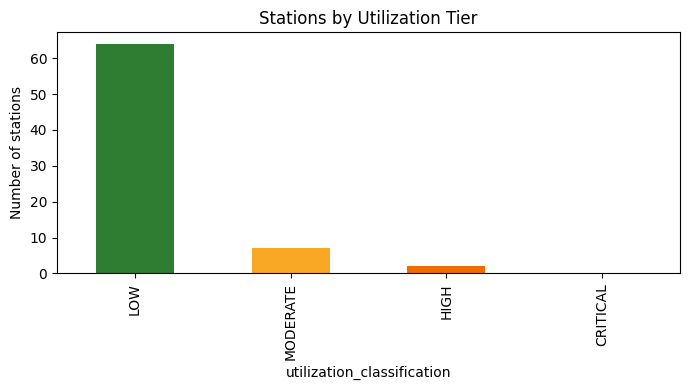

In [2]:
import matplotlib.pyplot as plt
counts = station_util['utilization_classification'].value_counts().reindex(['LOW','MODERATE','HIGH','CRITICAL']).fillna(0)
counts.plot(kind='bar', color=['#2E7D32','#F9A825','#EF6C00','#C62828'], figsize=(7,4), title='Stations by Utilization Tier')
plt.ylabel('Number of stations'); plt.tight_layout(); plt.show()

## Utilization by hour of day (network-wide average)

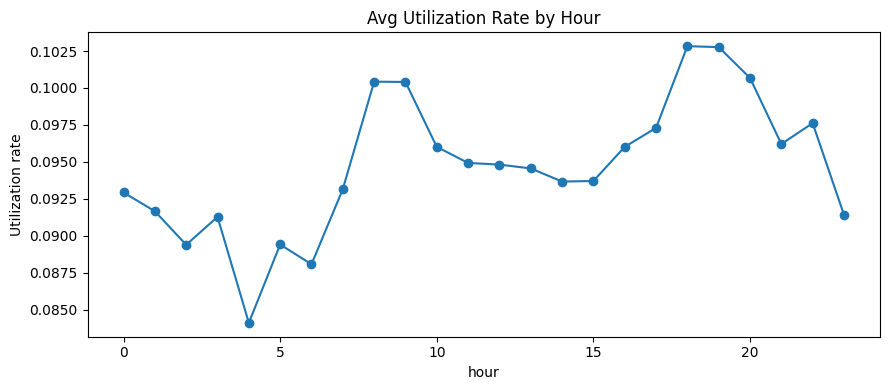

In [3]:
util_by_hour.set_index('hour')['utilization_rate'].plot(kind='line', marker='o', figsize=(9,4), title='Avg Utilization Rate by Hour')
plt.ylabel('Utilization rate'); plt.tight_layout(); plt.show()

## Utilization by city

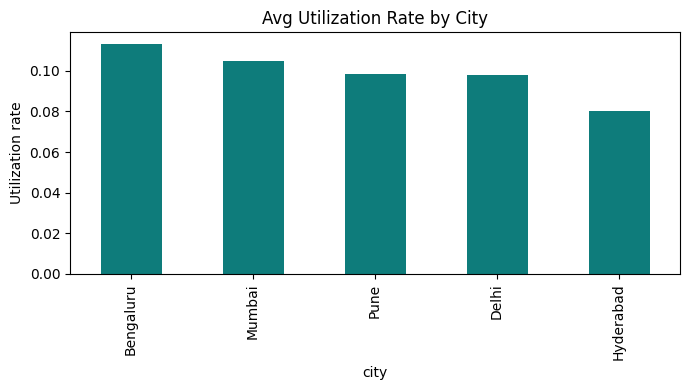

In [4]:
util_by_city.set_index('city')['avg_utilization_rate'].plot(kind='bar', figsize=(7,4), color='#0E7C7B', title='Avg Utilization Rate by City')
plt.ylabel('Utilization rate'); plt.tight_layout(); plt.show()

## Top 5 highest and lowest utilization stations

In [5]:
print('HIGHEST:')
print(station_util.sort_values('avg_utilization_rate', ascending=False).head(5)[['station_name','city','avg_utilization_rate','utilization_classification']])
print('\nLOWEST:')
print(station_util.sort_values('avg_utilization_rate').head(5)[['station_name','city','avg_utilization_rate','utilization_classification']])

HIGHEST:
              station_name       city  avg_utilization_rate  \
46   Jayanagar Ev Hub 1047  Bengaluru              0.363281   
34  Whitefield Ev Hub 1035  Bengaluru              0.355406   
30    Borivali Ev Hub 1031     Mumbai              0.346774   
4       Dwarka Ev Hub 1005      Delhi              0.181243   
21      Bandra Ev Hub 1022     Mumbai              0.178866   

   utilization_classification  
46                       HIGH  
34                       HIGH  
30                   MODERATE  
4                    MODERATE  
21                   MODERATE  

LOWEST:
               station_name       city  avg_utilization_rate  \
43  Indiranagar Ev Hub 1044  Bengaluru              0.041073   
63  Hitech City Ev Hub 1064  Hyderabad              0.044357   
3        Dwarka Ev Hub 1004      Delhi              0.050460   
14   Karol Bagh Ev Hub 1015      Delhi              0.050497   
37  Koramangala Ev Hub 1038  Bengaluru              0.050588   

   utilization_classificat